<a href="https://colab.research.google.com/github/Surendra098/Aos2/blob/main/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import sklearn

In [ ]:
print('numpy',np.__version__)
print('pandas',pd.__version__)
print('sklearn',sklearn.__version__)


numpy 2.0.2
pandas 2.2.2
sklearn 1.6.1


In [ ]:
df=pd.read_csv('/content/AAPL (4) (3).csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,03-01-2012,58.485714,58.928570,58.428570,58.747143,50.765709,75555200
1,04-01-2012,58.571430,59.240002,58.468571,59.062859,51.038536,65005500
2,05-01-2012,59.278572,59.792858,58.952858,59.718571,51.605175,67817400
3,06-01-2012,59.967144,60.392857,59.888573,60.342857,52.144630,79573200
4,09-01-2012,60.785713,61.107143,60.192856,60.247143,52.061932,98506100


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2011 entries, 0 to 2010
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2011 non-null   object 
 1   Open       2011 non-null   float64
 2   High       2011 non-null   float64
 3   Low        2011 non-null   float64
 4   Close      2011 non-null   float64
 5   Adj Close  2011 non-null   float64
 6   Volume     2011 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 110.1+ KB


In [ ]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
from sklearn.preprocessing import MinMaxScaler


In [ ]:
scaler=MinMaxScaler()
df['close_norm']=scaler.fit_transform(df[['Close']])

In [ ]:
# moving Averages
df['MA_10'] = df['Close'].rolling(window=10).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()


In [ ]:
df['MA_10'].mean()

np.float64(126.53274645374624)

In [ ]:
df['MA_50'].mean()

np.float64(125.71106171082569)

In [ ]:
# volatility
df['Volatility'] = df['Close'].rolling(window=10).std()

In [ ]:
df['Volatility'].std()

1.590889145220404

In [ ]:
# daily returns
df['Daily_Returns'] = df['Close'].pct_change()

In [ ]:
df['Daily_Returns'].pct_change()

,Daily_Returns
0,NaN
1,NaN
2,1.065803
3,-0.058380
4,-1.151731
...,...
2006,-8.878560
2007,-0.941743
2008,19.869955
2009,-1.019127


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
# convert Date column to datetime for time-series analysis
df['Date'] = pd.to_datetime(df['Date'],format='%d-%m-%Y')

In [ ]:
df=df.reset_index()
df.set_index('Date',inplace=True)

In [ ]:
df.columns=df.columns.str.strip()
df.columns

Index(['index', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'close_norm', 'MA_10', 'MA_50', 'Volatility', 'Daily_Returns'],
      dtype='object')

In [ ]:
## visualization part

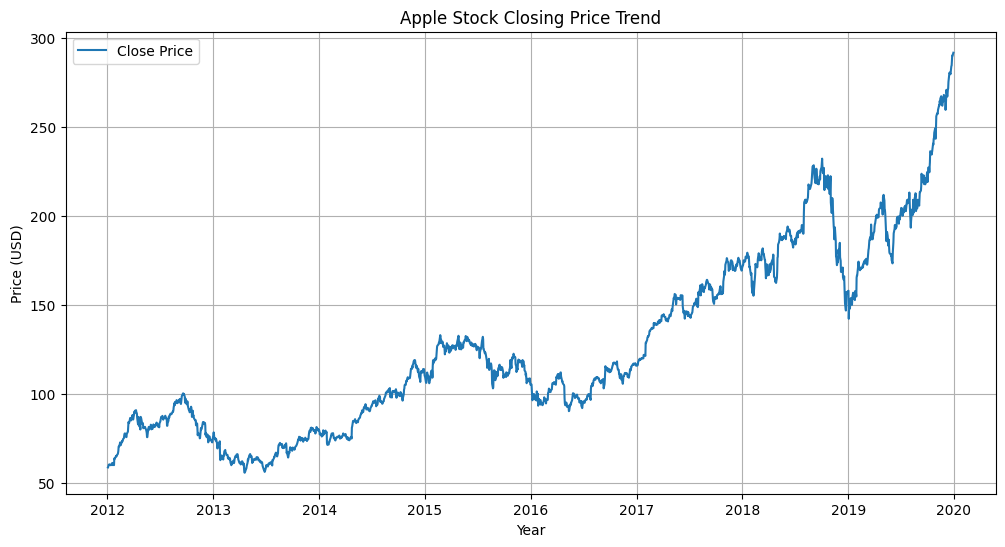

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Close'], label='Close Price')
plt.title("Apple Stock Closing Price Trend")
plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# moving averages
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA200'] = df['Close'].rolling(window=200).mean()

In [ ]:
df['MA50'].mean()

np.float64(125.71106171082569)

In [ ]:
df['MA200'].mean()

np.float64(123.55666973916391)

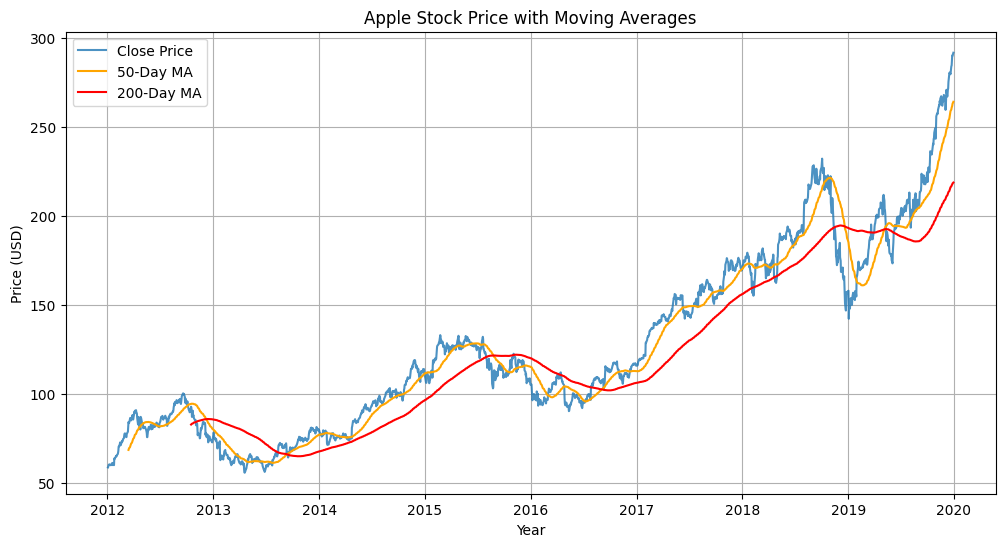

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Close'], label='Close Price', alpha=0.8)
plt.plot(df.index, df['MA50'], label='50-Day MA', color='orange')
plt.plot(df.index, df['MA200'], label='200-Day MA', color='red')
plt.title("Apple Stock Price with Moving Averages")
plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Plot 3: Volatility (30-day rolling standard deviation of returns)
df['Volatility_30'] = df['Daily_Returns'].rolling(window=30).std()
df['Volatility_30'].std()

0.0051688983683132505

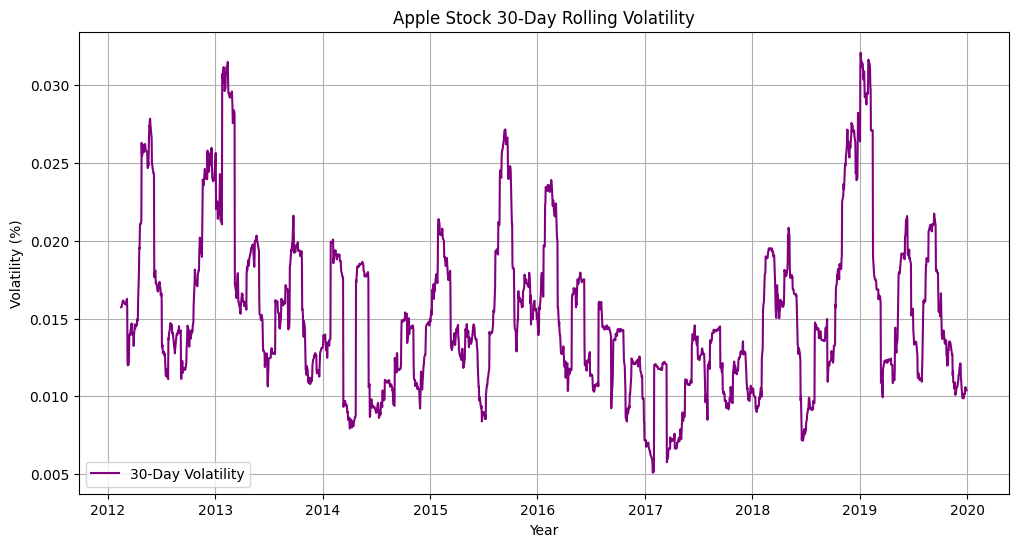

In [ ]:

plt.figure(figsize=(12,6))
plt.plot(df.index, df['Volatility_30'], label='30-Day Volatility', color='purple')
plt.title("Apple Stock 30-Day Rolling Volatility")
plt.xlabel("Year")
plt.ylabel("Volatility (%)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
## statistics models

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
data = df['Close']
data

,Close
Date,
2012-01-03,58.747143
2012-01-04,59.062859
2012-01-05,59.718571
2012-01-06,60.342857
2012-01-09,60.247143
...,...
2019-12-23,284.000000
2019-12-24,284.269989
2019-12-26,289.910004


In [ ]:
train_size = int(len(data) * 0.8)   # 80% train, 20% test
train, test = data[:train_size], data[train_size:]

In [ ]:
# --Fit ARIMA Model ---
# (p,d,q) = (5,1,0) can be adjusted later for tuning
model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [ ]:
# --Forecast same length as test set ---
forecast = model_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:

# --- Calculate Metrics ---
mae = mean_absolute_error(test, forecast)
mse = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((test - forecast) / test)) * 100

print("Model Evaluation Metrics:")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")

Model Evaluation Metrics:
MAE  : 25.3614
MSE  : 1156.4304
RMSE : 34.0063
MAPE : nan%


/tmp/ipython-input-2349166032.py:5: RuntimeWarning: '<' not supported between instances of 'int' and 'Timestamp', sort order is undefined for incomparable objects.
  mape = np.mean(np.abs((test - forecast) / test)) * 100


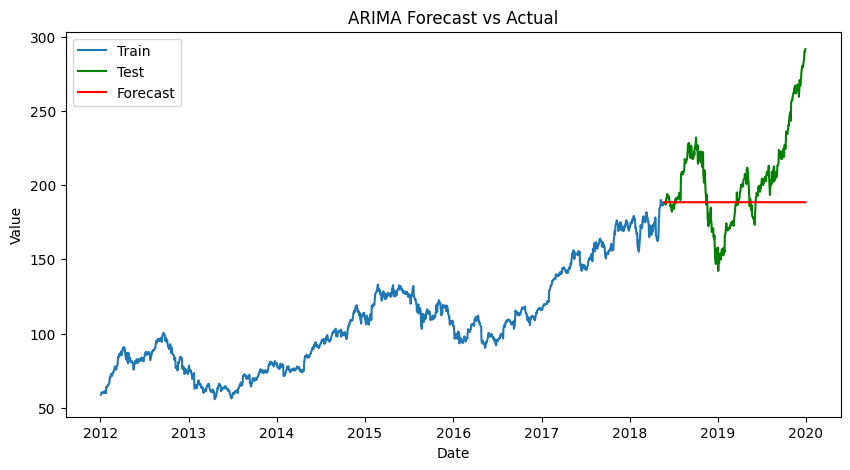

In [ ]:
# --- Plot Results ---
plt.figure(figsize=(10,5))
plt.plot(train, label='Train')
plt.plot(test, label='Test', color='green')
plt.plot(test.index, forecast, label='Forecast', color='red')
plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.show()

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:

# --- Split into Train and Test Sets ---
train_size = int(len(data) * 0.8)  # 80% training, 20% testing
train, test = data[:train_size], data[train_size:]



In [ ]:
# --- Fit SARIMA Model ---
# order(p,d,q): non-seasonal part
# seasonal_order(P,D,Q,s): seasonal part
# Here s = 12 means 12 months if your data is monthly
model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12))
model_fit = model.fit(disp=False)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [ ]:
# --- Forecast the Same Length as Test Set ---
forecast = model_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
# --- Calculate Metrics ---
mae = mean_absolute_error(test, forecast)
mse = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((test - forecast) / test)) * 100

print("Model Evaluation Metrics:")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")

Model Evaluation Metrics:
MAE  : 20.7884
MSE  : 694.0994
RMSE : 26.3458
MAPE : nan%


/tmp/ipython-input-853399495.py:5: RuntimeWarning: '<' not supported between instances of 'int' and 'Timestamp', sort order is undefined for incomparable objects.
  mape = np.mean(np.abs((test - forecast) / test)) * 100


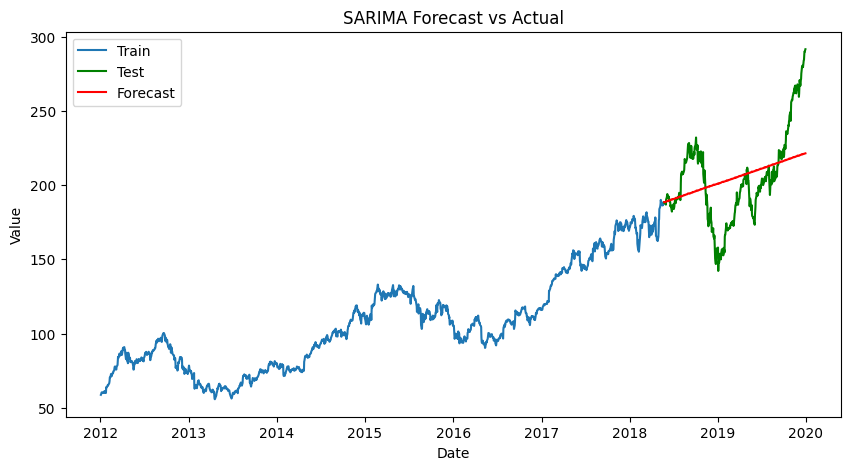

In [ ]:
# --- Plot Actual vs Forecast ---
plt.figure(figsize=(10,5))
plt.plot(train, label='Train')
plt.plot(test, label='Test', color='green')
plt.plot(test.index, forecast, label='Forecast', color='red')
plt.title("SARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.show()


In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [ ]:

# --- Split into Train and Test ---
train_size = int(len(data) * 0.8)  # 80% train, 20% test
train, test = data[:train_size], data[train_size:]

In [ ]:
# --- Fit Exponential Smoothing Model ---
# trend='add' means additive trend
# seasonal='add' means additive seasonality (can change to 'mul' if multiplicative)
# seasonal_periods=12 means yearly seasonality for monthly data
model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12)
hw_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [ ]:
# --- Forecast same length as test set ---
forecast = hw_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
# --- Calculate Metrics ---
mae = mean_absolute_error(test, forecast)
mse = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((test - forecast) / test)) * 100

print("Model Evaluation Metrics:")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")

Model Evaluation Metrics:
MAE  : 20.7714
MSE  : 695.3601
RMSE : 26.3697
MAPE : nan%


/tmp/ipython-input-853399495.py:5: RuntimeWarning: '<' not supported between instances of 'int' and 'Timestamp', sort order is undefined for incomparable objects.
  mape = np.mean(np.abs((test - forecast) / test)) * 100


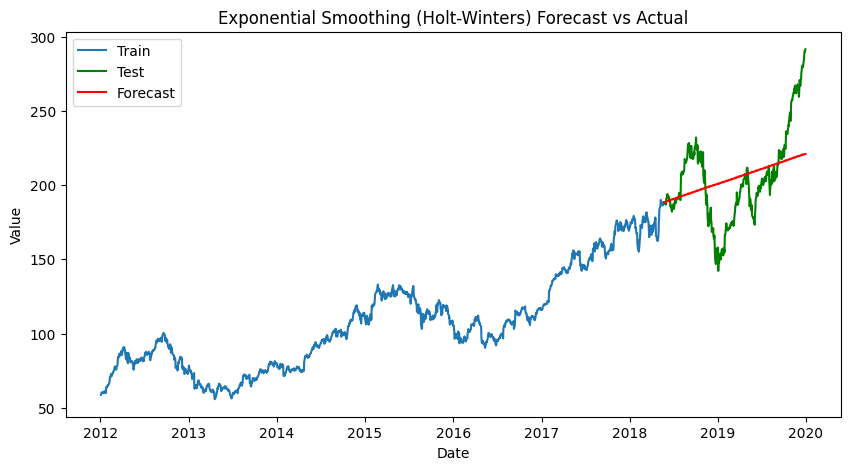

In [ ]:
# --- Plot Results ---
plt.figure(figsize=(10,5))
plt.plot(train, label='Train')
plt.plot(test, label='Test', color='green')
plt.plot(test.index, forecast, label='Forecast', color='red')
plt.title("Exponential Smoothing (Holt-Winters) Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.show()

In [ ]:
from keras.models import Sequential
from keras.layers import LSTM, Dense,Dropout
from sklearn.preprocessing import MinMaxScaler
import numpy as np

In [ ]:
# =========================================
data = df.filter(['Close'])
dataset = data.values
training_data_len = int(np.ceil(len(dataset) * 0.8))

In [ ]:
# Scale the data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data.values.reshape(-1,1))


In [ ]:
# =========================================
train_data = scaled_data[0:int(training_data_len), :]

X_train = []
y_train = []

for i in range(60, len(train_data)):
    X_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [ ]:
# 🧱 Build LSTM Model
# =========================================
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(25))
model.add(Dense(1))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# =========================================
model.compile(optimizer='adam', loss='mean_squared_error')
history = model.fit(X_train, y_train, batch_size=64, epochs=20)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - loss: 0.0213
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 186ms/step - loss: 0.0018
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 0.0010
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 7.8447e-04
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 7.1479e-04
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 7.2138e-04
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - loss: 6.7600e-04
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 7.3057e-04
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 6.0467e-04
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 6.9850e-04
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 5.6377e-04
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - loss: 5.5273e-04
Epoch 13/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - loss: 5.1046e-04
Epoch 14/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 5.5719e-04
Epoch 15/20
25/25 ━━━━━

In [ ]:
# =========================================
test_data = scaled_data[training_data_len - 60:, :]
X_test = []
y_test = dataset[training_data_len:, :]

for i in range(60, len(test_data)):
    X_test.append(test_data[i-60:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [ ]:
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step


In [ ]:
# =========================================
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
print("RMSE:", rmse)

RMSE: 6.401362736203805


In [ ]:
# =========================================
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions

/tmp/ipython-input-1565385134.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


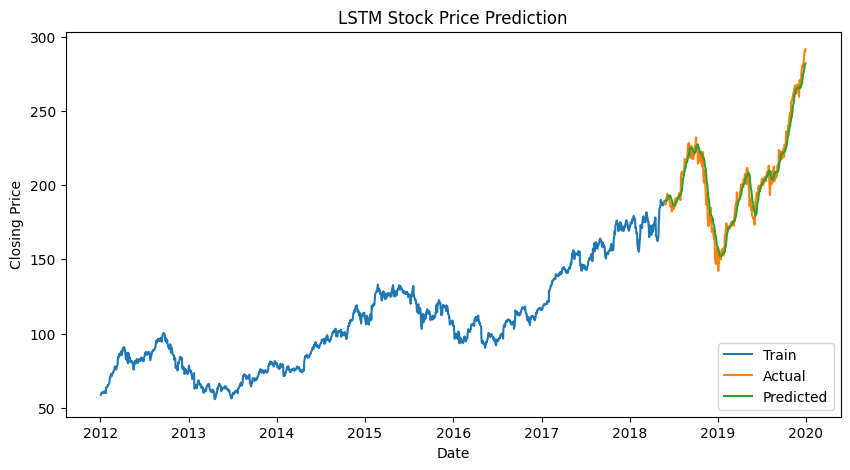

In [ ]:

plt.figure(figsize=(10,5))
plt.plot(train['Close'], label='Train Data')
plt.plot(valid[['Close', 'Predictions']])
plt.title('LSTM Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend(['Train', 'Actual', 'Predicted'], loc='lower right')
plt.show()

In [ ]:
## gated recurrent unit
from keras.layers import GRU
from keras.models import Sequential

In [ ]:
df.columns


Index(['index', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'close_norm', 'MA_10', 'MA_50', 'Volatility', 'Daily_Returns', 'MA50',
       'MA200', 'Volatility_30'],
      dtype='object')

In [ ]:

# --- Step 1: Prepare Data ---
data = df['Close'].values.reshape(-1, 1)


In [ ]:
# Scale data (important for neural networks)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

In [ ]:
# --- Step 2: Create Sequences (60 previous values to predict next one) ---
X, y = [], []
for i in range(60, len(scaled_data)):
    X.append(scaled_data[i-60:i, 0])
    y.append(scaled_data[i, 0])


X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))


In [ ]:
# --- Step 3: Split Train & Test ---
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]




In [ ]:

# --- Step 4: Build GRU Model ---
model = Sequential([GRU(50, return_sequences=True, input_shape=(X.shape[1], 1)), GRU(50), Dense(1)])

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 117ms/step - loss: 0.0163
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 1.9009e-04
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 1.5382e-04
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - loss: 1.2724e-04
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 1.1413e-04
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 1.2200e-04
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - loss: 1.0718e-04
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - loss: 1.0442e-04
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - loss: 1.1033e-04
Epoch 10/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - loss: 9.3453e-05
Epoch 11/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 8.7467e-05
Epoch 12/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 9.3526e-05
Epoch 13/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - loss: 8.4558e-05
Epoch 14/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 8.1001e-05
Epoch 15/20
49/49 ━━━━━━━━━━━

In [ ]:
# --- Step 5: Make Predictions ---
y_pred_scaled = model.predict(X_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step


In [ ]:
# Inverse scale predictions
y_pred = scaler.inverse_transform(y_pred_scaled)
y_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

In [ ]:

# --- Step 6: Calculate Metrics ---
mae = mean_absolute_error(y_actual, y_pred)
mse = mean_squared_error(y_actual, y_pred)
rmse = np.sqrt(mse)

print("Model Evaluation Metrics:")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

Model Evaluation Metrics:
MAE  : 2.8383
MSE  : 14.6159
RMSE : 3.8231


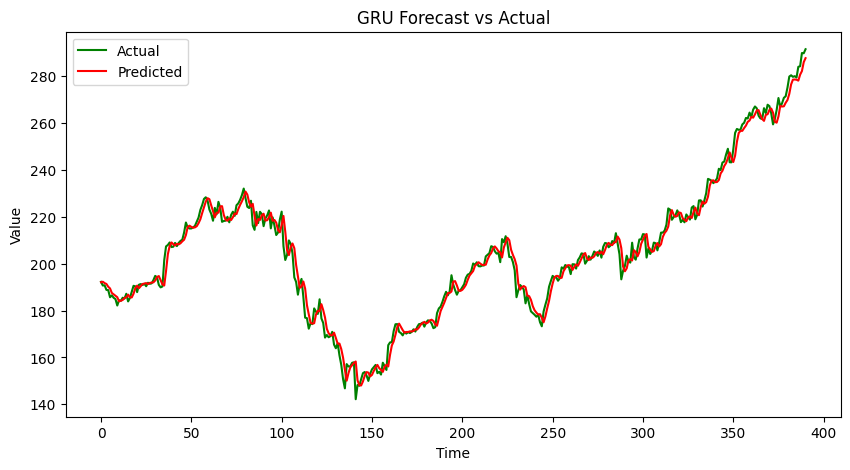

In [ ]:
# --- Step 7: Plot Output ---plt.figure(figsize=(10,5))
plt.plot(y_actual, label='Actual', color='green')
plt.plot(y_pred, label='Predicted', color='red')
plt.title("GRU Forecast vs Actual")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()


FEATURE SELECTION

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

In [ ]:

# --- Step 1: Prepare Data ---
data = df[['Close']].copy()  # make sure 'Close' column exists

# Scale data
scaler = MinMaxScaler(feature_range=(0, 1))
data['Scaled'] = scaler.fit_transform(data[['Close']])

In [ ]:
# --- Step 2: Create Lag Features ---
def create_lag_features(series, n_lags=10):
    df_lag = pd.DataFrame()
    for i in range(1, n_lags + 1):
        df_lag[f'lag_{i}'] = series.shift(i)
    df_lag['target'] = series.values
    df_lag.dropna(inplace=True)
    return df_lag

n_lags = 10
lagged_data = create_lag_features(data['Scaled'], n_lags=n_lags)

In [ ]:

# Split features & target
X = lagged_data.drop('target', axis=1)
y = lagged_data['target']

In [ ]:
# --- Step 3: Split Train & Test ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


In [ ]:
# --- Step 4: Build & Train XGBoost Model ---
xgb_model = XGBRegressor( n_estimators=200,learning_rate=0.05,max_depth=5,
                         subsample=0.8,colsample_bytree=0.8,random_state=42)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:

# --- Step 5: Make Predictions ---
y_pred_scaled = xgb_model.predict(X_test)

In [ ]:

# Inverse transform
y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_actual = scaler.inverse_transform(y_test.values.reshape(-1, 1))

In [ ]:

# --- Step 6: Evaluate ---
mae = mean_absolute_error(y_actual, y_pred)
mse = mean_squared_error(y_actual, y_pred)
rmse = np.sqrt(mse)

print("\n📊 XGBoost Model Performance:")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")


📊 XGBoost Model Performance:
MAE  : 22.1193
MSE  : 1077.8627
RMSE : 32.8308


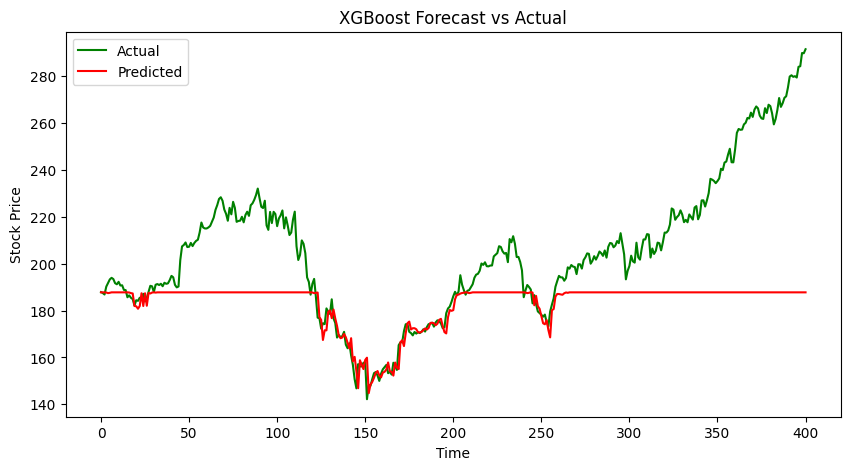

In [ ]:

# --- Step 7: Plot Actual vs Predicted ---
plt.figure(figsize=(10,5))
plt.plot(y_actual, color='green', label='Actual')
plt.plot(y_pred, color='red', label='Predicted')
plt.title("XGBoost Forecast vs Actual")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
 ##--- Step 3: Split Train & Test ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:

# --- Step 4: Build & Train Random Forest Model ---
rf_model = RandomForestRegressor(  n_estimators=200, max_depth=10,random_state=42)

rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [ ]:
# --- Step 5: Make Predictions ---
y_pred_scaled = rf_model.predict(X_test)

In [ ]:
# Inverse transform
y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_actual = scaler.inverse_transform(y_test.values.reshape(-1, 1))

In [ ]:
# --- Step 6: Evaluate ---
mae = mean_absolute_error(y_actual, y_pred)
mse = mean_squared_error(y_actual, y_pred)
rmse = np.sqrt(mse)

print("\n📊 Random Forest Model Performance:")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")


📊 Random Forest Model Performance:
MAE  : 22.3495
MSE  : 1095.5724
RMSE : 33.0994


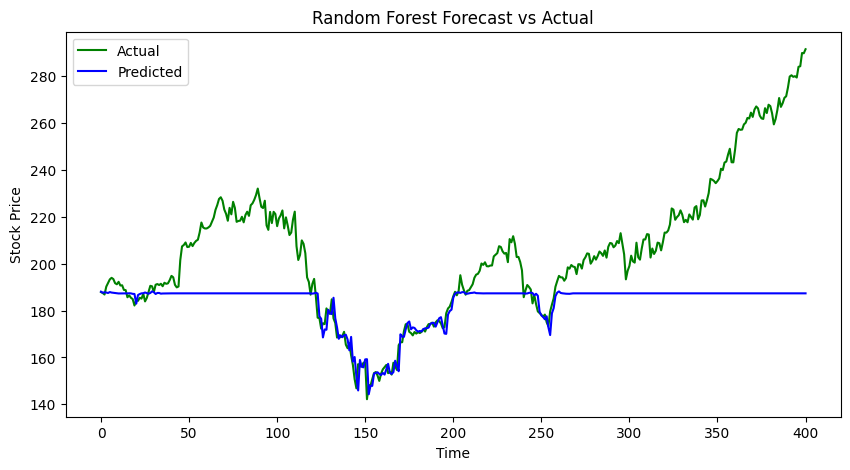

In [ ]:
# --- Step 7: Plot Actual vs Predicted ---
plt.figure(figsize=(10,5))
plt.plot(y_actual, color='green', label='Actual')
plt.plot(y_pred, color='blue', label='Predicted')
plt.title("Random Forest Forecast vs Actual")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

In [ ]:
pip install streamlit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 85.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 104.4 MB/s eta 0:00:00


In [ ]:
import joblib

joblib.dump(model, "apple_stock_model.pkl")


['apple_stock_model.pkl']

In [ ]:
import streamlit as st
import pandas as pd
import joblib

In [ ]:
# Load model
model = joblib.load("apple_stock_model.pkl")

st.title(" Apple Stock Price Prediction (Next 30 Days)")

2025-10-23 06:30:39.003 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-23 06:30:39.472 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-10-23 06:30:39.473 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-23 06:30:39.474 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [ ]:
# Upload new data
uploaded_file = st.file_uploader("Upload your CSV data", type=["csv"])

2025-10-23 06:30:39.486 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-23 06:30:39.487 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-23 06:30:39.488 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-23 06:30:39.490 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-23 06:30:39.491 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-23 06:30:39.494 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [ ]:

if uploaded_file is not None:
    df = pd.read_csv(uploaded_file)
    st.write("Uploaded Data Preview:", df.head())

In [ ]:
# Get the last 60 days of scaled data (or whatever your input window is)
last_60_days = scaled_data[-60:]
X_future = []
X_future.append(last_60_days)
X_future = np.array(X_future)
X_future = np.reshape(X_future, (X_future.shape[0], X_future.shape[1], 1))


In [ ]:

# Predict next value
forecast_scaled = model.predict(X_future)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step


In [ ]:

# Inverse transform to get real stock price
forecast = scaler.inverse_transform(forecast_scaled)

print("Predicted next day's stock price:", forecast)


Predicted next day's stock price: [[289.0355]]


In [ ]:
##  prediction of upcoming 30 days

In [ ]:
future_predictions = []
last_60 = list(scaled_data[-60:].flatten())  # flatten ensures it's 1D

for i in range(30):
    X_test = np.array(last_60[-60:]).reshape(1, 60, 1)
    pred = model.predict(X_test, verbose=0)
    pred_value = float(pred[0, 0])  # convert array to single float
    future_predictions.append(pred_value)
    last_60.append(pred_value)

In [ ]:
# Convert back to original scale
forecast_30 = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))
print(forecast_30)

[[289.03549127]
 [287.9827218 ]
 [286.60416101]
 [285.23151553]
 [283.89129884]
 [282.58826004]
 [281.32320002]
 [280.09597828]
 [278.90592037]
 [277.75216922]
 [276.63369914]
 [275.54944227]
 [274.49820431]
 [273.47872072]
 [272.48990959]
 [271.53046421]
 [270.59928866]
 [269.69518861]
 [268.81718053]
 [267.96405606]
 [267.13494408]
 [266.32886103]
 [265.54493578]
 [264.78225504]
 [264.04004603]
 [263.31755002]
 [262.61393801]
 [261.92864799]
 [261.26092122]
 [260.61012543]]
